# **1. Install Library**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --upgrade pymupdf
!pip install nltk
!pip install networkx
!pip install matplotlib
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 116.7 MB/s eta 0:00:00


# **2. Import Library**

In [ ]:
import pymupdf
import nltk
import re
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from collections import defaultdict, Counter
from IPython.display import display

# **3. Download Resources NLTK**

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **4. Load & Ekstrak PDF Menjadi Teks**

In [ ]:
paper = '/content/drive/MyDrive/TUGAS8/Paper.pdf'

doc = pymupdf.open(paper)

full_text = ""
for page in doc:
    full_text += page.get_text()

print("Jumlah karakter hasil ekstraksi:", len(full_text))
print("\nPreview teks hasil ekstraksi:\n")
print(full_text)

Jumlah karakter hasil ekstraksi: 56017

Preview teks hasil ekstraksi:

Paper—Word Embedding for High Performance Cross-Language Plagiarism Detection Techniques 
Word Embedding for High Performance Cross-Language 
Plagiarism Detection Techniques 
https://doi.org/10.3991/ijim.v17i10.38891  
Chaimaa Bouaine(), Faouzia Benabbou, Imane Sadgali  
Laboratory of Modeling and Information Technology, University Hassan II, Casablanca,  
Morocco 
chaimaa.bouaine-etu@etu.univh2c.ma 
Abstract—Academic plagiarism has become a serious concern as it leads to 
the retardation of scientific progress and violation of intellectual property. In this 
context, we make a study aiming at the detection of cross-linguistic plagiarism 
based on Natural language Preprocessing (NLP), Embedding Techniques, and 
Deep Learning. Many systems have been developed to tackle this problem, and 
many rely on machine learning and deep learning methods. In this paper, we 
propose Cross-language Plagiarism Detection (CL-PD) me

# **5. Preprocessing Teks (Bersih & Formal)**

In [ ]:
# CELL AWAL (WAJIB)
import re

text = full_text   # hasil ekstraksi PyMuPDF

print("ORIGINAL TEXT LENGTH:", len(text))
print(text[:500])


ORIGINAL TEXT LENGTH: 56017
Paper—Word Embedding for High Performance Cross-Language Plagiarism Detection Techniques 
Word Embedding for High Performance Cross-Language 
Plagiarism Detection Techniques 
https://doi.org/10.3991/ijim.v17i10.38891  
Chaimaa Bouaine(), Faouzia Benabbou, Imane Sadgali  
Laboratory of Modeling and Information Technology, University Hassan II, Casablanca,  
Morocco 
chaimaa.bouaine-etu@etu.univh2c.ma 
Abstract—Academic plagiarism has become a serious concern as it leads to 
the retardation of sc


In [ ]:
patterns_metadata = [
    r'jurnal\s+[a-z\s]+',
    r'volume\s+\d+',
    r'page\s+\d+[\-\–]\d+',
    r'issn\s+\d+[\-\d\s\(\)a-z]+',
    r'available\s+online\s+at\s+\S+',
    r'doi\s*[:]*\s*\S+',
    r'copyright\s+©*\s*\d+',
    r'submitted\s*[:]*.*?published\s*[:]*\s*\d+',
    r'email\s*addresses*[:]*\s*\S+'
    r'\b(authors?|email|submitted|accepted|published)\b.*',
]

header_patterns = [
    r'Paper[\—\-].*?\n',
    r'iJIM\s*[\—\-]?\s*Vol\.\s*\d+.*?\n'
]

text_meta = text

for p in patterns_metadata:
    text_meta = re.sub(p, ' ', text_meta, flags=re.IGNORECASE)

for p in header_patterns:
    text_meta = re.sub(p, ' ', text_meta, flags=re.IGNORECASE)

print("AFTER METADATA LENGTH:", len(text_meta))
print(text_meta[:500])


AFTER METADATA LENGTH: 52823
 Word Embedding for High Performance Cross-Language 
Plagiarism Detection Techniques 
https://   
Chaimaa Bouaine(), Faouzia Benabbou, Imane Sadgali  
Laboratory of Modeling and Information Technology, University Hassan II, Casablanca,  
Morocco 
chaimaa.bouaine-etu@etu.univh2c.ma 
Abstract—Academic plagiarism has become a serious concern as it leads to 
the retardation of scientific progress and violation of intellectual property. In this 
context, we make a study aiming at the detection of cr


In [ ]:
text_1 = text_meta.replace('\n', ' ')
text_1 = text_1.lower()
text_1 = re.sub(r'\S+@\S+', ' ', text_1)
text_1 = re.sub(r'http\S+|www\S+|doi\S+', ' ', text_1)
text_1 = re.sub(r'(?<![a-z])\d+(?![a-z])', ' ', text_1)
text_1 = re.sub(r'[^a-zA-Z\.\?\!\s]', ' ', text_1)
text_1 = re.sub(r'\s+', ' ', text_1)

print("STEP 1 LENGTH:", len(text_1))
print(text_1)


STEP 1 LENGTH: 46672
 word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property. in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning. many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods. in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model. embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance. to show the effectiveness of our method we condu

In [ ]:
text_2 = re.split(
    r'references|daftar pustaka|bibliography',
    text_1,
    flags=re.IGNORECASE
)[0]

print("STEP 3 LENGTH:", len(text_2))
print(text_2)


STEP 3 LENGTH: 37085
 word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property. in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning. many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods. in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model. embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance. to show the effectiveness of our method we condu

In [ ]:
text_3 = re.sub(r'\[[0-9]+\]', ' ', text_2)
text_3 = re.sub(r'\([0-9]{4}\)', ' ', text_3)
text_3 = re.sub(r'\bet\s+al\.?\b', ' ', text_3, flags=re.IGNORECASE)

for w in [r'\betc\b', r'\bdll\b', r'\bdst\b', r'\bdsb\b']:
    text_3 = re.sub(w, ' ', text_3)

print("STEP 3 LENGTH:", len(text_3))
print(text_3)

STEP 3 LENGTH: 37009
 word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property. in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning. many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods. in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model. embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance. to show the effectiveness of our method we condu

In [ ]:
footer_patterns = [
    r'ijim\s*[–\-—]?\s*vol\.?\s*\d+\s*,?\s*no\.?\s*\d+\s*,?\s*\d{4}',
    r'ijim\s+vol\.?\s+no\.?'
]

text_4 = text_3
for p in footer_patterns:
    text_4 = re.sub(p, ' ', text_4)

print("STEP 3 LENGTH:", len(text_4))
print(text_4)


STEP 3 LENGTH: 36901
 word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property. in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning. many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods. in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model. embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance. to show the effectiveness of our method we condu

In [ ]:
text_5 = text_4
text_5 = re.sub(r'\b[iv]\b', ' ', text_5)          # i / v sendiri
text_5 = re.sub(r'\bv\s+i\b', ' ', text_5)
text_5 = re.sub(r'\bi\s+v\b', ' ', text_5)

text_5 = re.sub(r'\s+', ' ', text_5)

print("STEP 4 LENGTH:", len(text_5))
print(text_5)


STEP 4 LENGTH: 36858
 word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property. in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning. many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods. in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model. embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance. to show the effectiveness of our method we condu

In [ ]:
text_6 = text_5
text_6 = re.sub(
    r'\b(section|figure|table)\s+(shows?|presents?|describes?)\b.*?\.',
    ' ',
    text_6,
    flags=re.IGNORECASE
)
print("STEP 4 LENGTH:", len(text_6))
print(text_6)


STEP 4 LENGTH: 36267
 word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property. in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning. many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods. in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model. embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance. to show the effectiveness of our method we condu

In [ ]:
final_text = re.sub(r'\s+', ' ', text_6).strip()

print("FINAL LENGTH:", len(final_text))
print(final_text)


FINAL LENGTH: 36251
word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property. in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning. many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods. in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model. embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance. to show the effectiveness of our method we conduct

# **6. Ekstraksi Kalimat (NLTK)**

In [ ]:
sentence_list = sent_tokenize(final_text)

print("Jumlah kalimat:", len(sentence_list))
print(sentence_list[:5])

Jumlah kalimat: 430
['word embedding for high performance cross language plagiarism detection techniques chaimaa bouaine faouzia benabbou imane sadgali laboratory of modeling and information technology university hassan ii casablanca morocco abstract academic plagiarism has become a serious concern as it leads to the retardation of scientific progress and violation of intellectual property.', 'in this context we make a study aiming at the detection of cross linguistic plagiarism based on natural language preprocessing nlp embedding techniques and deep learning.', 'many systems have been developed to tackle this problem and many rely on machine learning and deep learning methods.', 'in this paper we propose cross language plagiarism detection cl pd method based on doc vec embedding techniques and a siamese long short term memory slstm model.', 'embedding techniques help capture the text s contextual meaning and improve the cl pd system s performance.']


In [ ]:
short_sentences = [s for s in sentence_list if len(s.split()) < 5]

print("Jumlah kalimat < 5 kata:", len(short_sentences))
print(short_sentences[:10])


Jumlah kalimat < 5 kata: 132
['a precision of .', 'a recall of .', 'aljuaid .', 'nguyen .', '.', 'glava .', 'mahmoud .', '.', 'alotaibi .', '.']


In [ ]:
filtered_sentences = [
    sent for sent in sentence_list
    if len(sent.split()) >= 5
]
print("Jumlah kalimat setelah filtering:", len(filtered_sentences))

Jumlah kalimat setelah filtering: 298


In [ ]:
# Tampilkan kalimat
df_sentences = pd.DataFrame(filtered_sentences, columns=['kalimat'])
display(df_sentences)

,kalimat
0,word embedding for high performance cross lang...
1,in this context we make a study aiming at the ...
2,many systems have been developed to tackle thi...
3,in this paper we propose cross language plagia...
4,embedding techniques help capture the text s c...
...,...
293,the use of the deep learning technique slstm i...
294,the experiments demonstrated that the doc vec ...
295,and a very low loss in the test phase.
296,the method was able to interpret sequential in...


**bersihkan tanda baca (wajib setelah kalimat terbentuk, bukan sebelum)**

In [ ]:
import re

def clean_sentence(sent):
    # lowercase
    sent = sent.lower()

    # hapus tanda baca kecuali titik (opsional)
    sent = re.sub(r'[^a-z\s]', ' ', sent)

    # rapikan spasi
    sent = re.sub(r'\s+', ' ', sent)

    return sent.strip()


In [ ]:
clean_sentences = []

for sent in filtered_sentences:
    cleaned = clean_sentence(sent)
    if len(cleaned.split()) >= 5:   # jaga agar tetap layak word graph
        clean_sentences.append(cleaned)

In [ ]:
df_clean_sentences = pd.DataFrame(clean_sentences, columns=['kalimat_bersih'])
display(df_clean_sentences)

,kalimat_bersih
0,word embedding for high performance cross lang...
1,in this context we make a study aiming at the ...
2,many systems have been developed to tackle thi...
3,in this paper we propose cross language plagia...
4,embedding techniques help capture the text s c...
...,...
283,the use of the deep learning technique slstm i...
284,the experiments demonstrated that the doc vec ...
285,and a very low loss in the test phase
286,the method was able to interpret sequential in...


In [ ]:
# simpan hasil kalimat ke csv
# periksa hasil ekstrak kalimat apakah sudah bagus? apakah sudah benar benar ke ekstrak?
df_clean_sentences.to_csv("Paper.csv", index=False, encoding="utf-8")

In [ ]:
from nltk.corpus import stopwords

# Stopword (dengan pengecualian istilah ilmiah penting)
stop_words = set(stopwords.words('english')) - {
    "not", "no", "nor", "without",
    "between", "across", "based", "using",
    "method", "model", "data", "system",
    "language", "cross", "plagiarism"
}

# =========================
# HITUNG STOPWORD TERHAPUS
# =========================
removed_stopwords_count = 0

for s in df_clean_sentences["kalimat_bersih"]:
    words = s.split()
    removed_stopwords_count += sum(1 for w in words if w in stop_words)

# =========================
# STOPWORD REMOVAL
# =========================
df_clean_sentences["kalimat_final"] = df_clean_sentences["kalimat_bersih"].apply(
    lambda s: " ".join(w for w in s.split() if w not in stop_words)
)

# =========================
# OUTPUT INFORMASI
# =========================
print("Jumlah kalimat setelah stopword removal:", len(df_clean_sentences))
print("Jumlah stopword digunakan:", len(stop_words))
print("Jumlah stopword yang dihapus dari teks:", removed_stopwords_count)


Jumlah kalimat setelah stopword removal: 288
Jumlah stopword digunakan: 194
Jumlah stopword yang dihapus dari teks: 2005


In [ ]:
df_clean_sentences

,kalimat_bersih,kalimat_final
0,word embedding for high performance cross lang...,word embedding high performance cross language...
1,in this context we make a study aiming at the ...,context make study aiming detection cross ling...
2,many systems have been developed to tackle thi...,many systems developed tackle problem many rel...
3,in this paper we propose cross language plagia...,paper propose cross language plagiarism detect...
4,embedding techniques help capture the text s c...,embedding techniques help capture text context...
...,...,...
283,the use of the deep learning technique slstm i...,use deep learning technique slstm improved per...
284,the experiments demonstrated that the doc vec ...,experiments demonstrated doc vec slstm model a...
285,and a very low loss in the test phase,low loss test phase
286,the method was able to interpret sequential in...,method able interpret sequential information m...


# **7. Tokenisasi Kata & Stopword Removal**

## **A. Unigram**

In [ ]:
from nltk.tokenize import word_tokenize

# Unigram tokenization
df_clean_sentences["unigram"] = df_clean_sentences["kalimat_final"].apply(
    lambda s: word_tokenize(s)
)

# Gabungkan semua unigram
all_unigrams = [w for sent in df_clean_sentences["unigram"] for w in sent]

# Output
print("Jumlah kalimat:", len(df_clean_sentences))
print("Jumlah total unigram:", len(all_unigrams))
# print("\nContoh unigram (5 baris pertama):")
# print(df_clean_sentences["unigram"].head())
print(all_unigrams)

Jumlah kalimat: 288
Jumlah total unigram: 3657
['word', 'embedding', 'high', 'performance', 'cross', 'language', 'plagiarism', 'detection', 'techniques', 'chaimaa', 'bouaine', 'faouzia', 'benabbou', 'imane', 'sadgali', 'laboratory', 'modeling', 'information', 'technology', 'university', 'hassan', 'ii', 'casablanca', 'morocco', 'abstract', 'academic', 'plagiarism', 'become', 'serious', 'concern', 'leads', 'retardation', 'scientific', 'progress', 'violation', 'intellectual', 'property', 'context', 'make', 'study', 'aiming', 'detection', 'cross', 'linguistic', 'plagiarism', 'based', 'natural', 'language', 'preprocessing', 'nlp', 'embedding', 'techniques', 'deep', 'learning', 'many', 'systems', 'developed', 'tackle', 'problem', 'many', 'rely', 'machine', 'learning', 'deep', 'learning', 'methods', 'paper', 'propose', 'cross', 'language', 'plagiarism', 'detection', 'cl', 'pd', 'method', 'based', 'doc', 'vec', 'embedding', 'techniques', 'siamese', 'long', 'short', 'term', 'memory', 'slstm', '

## **B. Bigram**

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

# Bigram tokenization per kalimat
df_clean_sentences["bigram"] = df_clean_sentences["kalimat_final"].apply(
    lambda s: list(ngrams(word_tokenize(s), 2))
)

# Gabungkan semua bigram jadi satu baris
all_bigrams = [bg for sent in df_clean_sentences["bigram"] for bg in sent]

print("Jumlah kalimat:", len(df_clean_sentences))
print("Jumlah total bigram:", len(all_bigrams))
# print("\nSEMUA BIGRAM (1 BARIS):\n")
print(all_bigrams)


Jumlah kalimat: 288
Jumlah total bigram: 3369
[('word', 'embedding'), ('embedding', 'high'), ('high', 'performance'), ('performance', 'cross'), ('cross', 'language'), ('language', 'plagiarism'), ('plagiarism', 'detection'), ('detection', 'techniques'), ('techniques', 'chaimaa'), ('chaimaa', 'bouaine'), ('bouaine', 'faouzia'), ('faouzia', 'benabbou'), ('benabbou', 'imane'), ('imane', 'sadgali'), ('sadgali', 'laboratory'), ('laboratory', 'modeling'), ('modeling', 'information'), ('information', 'technology'), ('technology', 'university'), ('university', 'hassan'), ('hassan', 'ii'), ('ii', 'casablanca'), ('casablanca', 'morocco'), ('morocco', 'abstract'), ('abstract', 'academic'), ('academic', 'plagiarism'), ('plagiarism', 'become'), ('become', 'serious'), ('serious', 'concern'), ('concern', 'leads'), ('leads', 'retardation'), ('retardation', 'scientific'), ('scientific', 'progress'), ('progress', 'violation'), ('violation', 'intellectual'), ('intellectual', 'property'), ('context', 'make

# **8. Co-Occurrence Matrix**

In [ ]:
tokens_per_sentence = []

for sent in filtered_sentences:
    tokens = word_tokenize(sent.lower())

    # filter token
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words]

    # unigram
    sentence_tokens = tokens.copy()

    # bigram (jadi 1 token)
    if len(tokens) >= 2:
        sentence_tokens += [' '.join(bg) for bg in ngrams(tokens, 2)]

    tokens_per_sentence.append(sentence_tokens)

print("Jumlah kalimat:", len(tokens_per_sentence))


Jumlah kalimat: 298


In [ ]:
cooc_dict = defaultdict(lambda: defaultdict(int))

for sentence in tokens_per_sentence:
    unique_tokens = list(set(sentence))  # hindari hitung ganda

    for i in range(len(unique_tokens)):
        for j in range(len(unique_tokens)):
            if i != j:
                w1 = unique_tokens[i]
                w2 = unique_tokens[j]
                cooc_dict[w1][w2] += 1
cooc_df = pd.DataFrame(cooc_dict).fillna(0).astype(int)
print("Ukuran Co-occurrence Matrix:", cooc_df.shape)

cooc_df.head(20)


Ukuran Co-occurrence Matrix: (3744, 3744)


,scientific progress,high performance,benabbou,plagiarism detection,violation,violation intellectual,scientific,word,language plagiarism,techniques,...,techniques generalize,work aim,extend current,impact document,document size,performance integration,aim extend,pairs study,current methodology,integration techniques
high performance,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
benabbou,1,1,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
plagiarism detection,1,1,1,0,1,1,1,1,4,3,...,0,0,0,0,0,0,0,0,0,0
violation,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
violation intellectual,1,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
scientific,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
word,1,1,1,1,1,1,1,0,1,10,...,0,0,0,0,0,0,0,0,0,0
language plagiarism,1,1,1,4,1,1,1,1,0,3,...,0,0,0,0,0,0,0,0,0,0
techniques,1,1,1,3,1,1,1,10,3,0,...,1,1,1,1,1,1,1,1,1,1
embedding high,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


# **9. Word Graph (NetworkX)**

In [ ]:
import networkx as nx

G = nx.Graph()

# Ambil token dari co-occurrence matrix
tokens = cooc_df.index.tolist()

# Tambahkan node
G.add_nodes_from(tokens)

# Tambahkan edge berdasarkan matrix
for i, token_i in enumerate(tokens):
    for j, token_j in enumerate(tokens):
        weight = cooc_df.iloc[i, j]
        if weight > 0 and i < j:  # hindari edge ganda
            G.add_edge(token_i, token_j, weight=weight)

print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())


Jumlah node: 3744
Jumlah edge: 88798


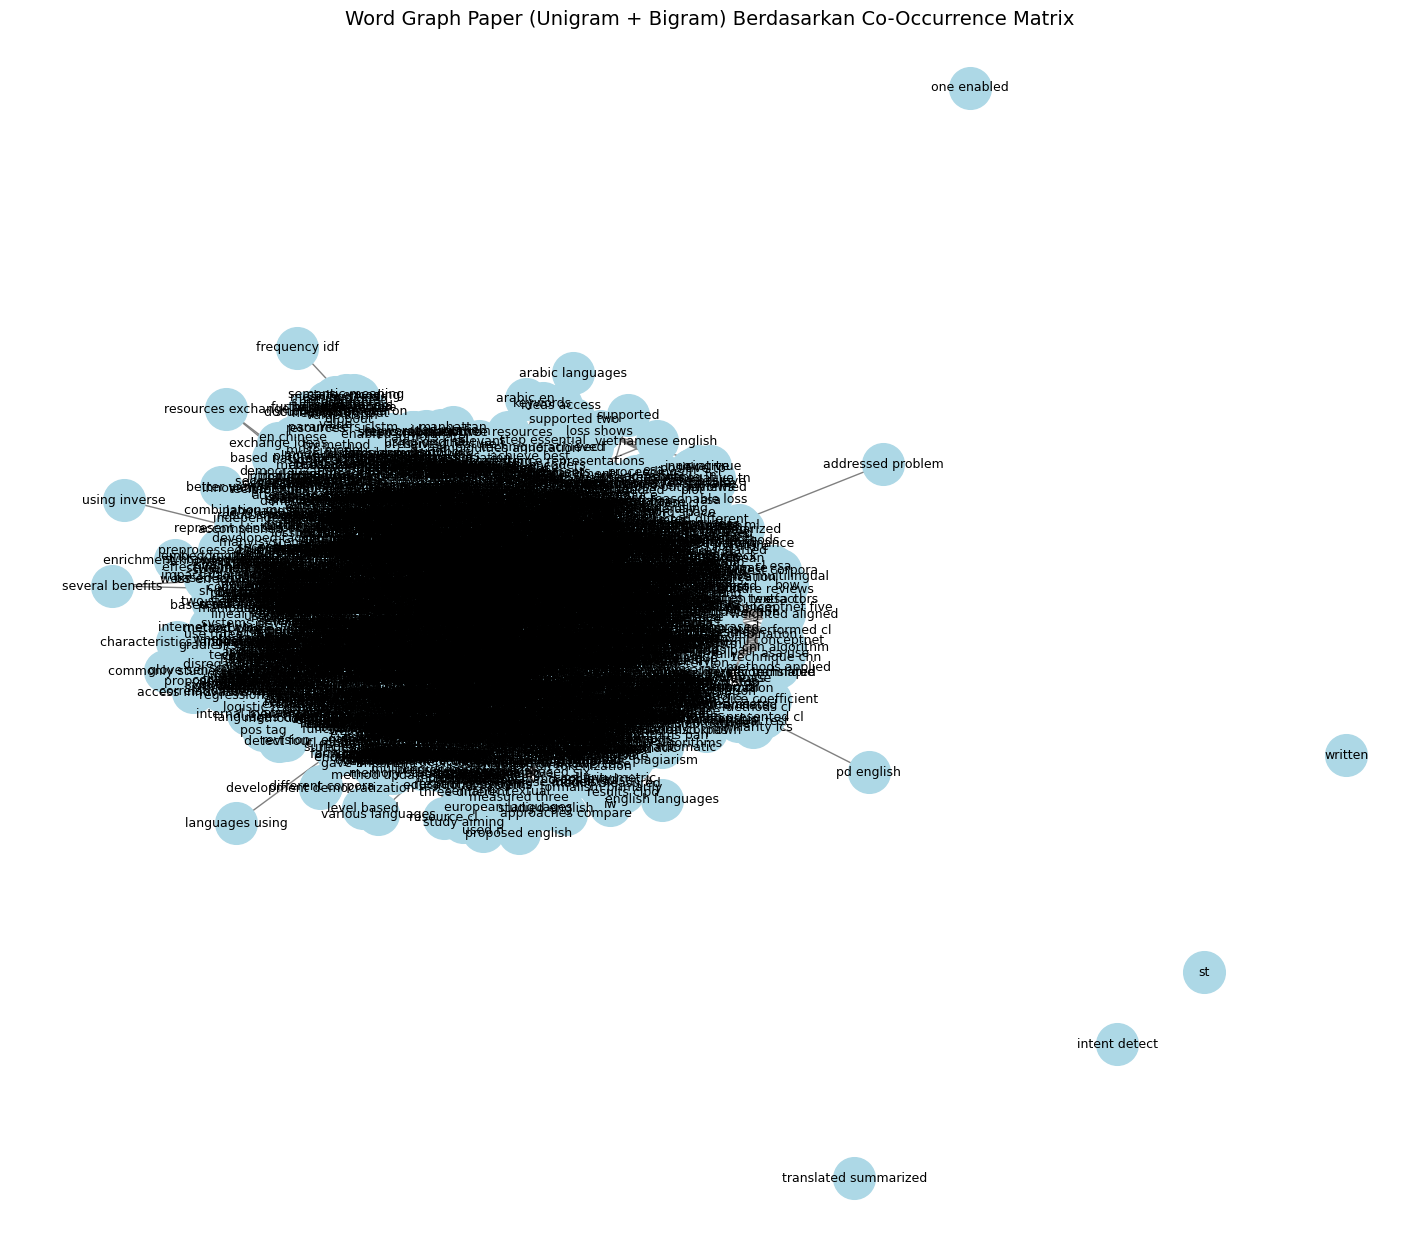

In [ ]:
# Visualisasi Word Graph
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(G, k=0.7, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=900,
    node_color='lightblue',
    font_size=9,
    edge_color='gray'
)

plt.title(
    "Word Graph Paper (Unigram + Bigram) Berdasarkan Co-Occurrence Matrix",
    fontsize=14
)
plt.show()

In [ ]:
G_pruned = G.copy()

# 1. edge weight pruning
G_pruned.remove_edges_from(
    [(u, v) for u, v, d in G_pruned.edges(data=True) if d["weight"] < 2]
)

# 2. remove isolated nodes
G_pruned.remove_nodes_from(list(nx.isolates(G_pruned)))

print("Sebelum pruning:")
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

print("Sesudah pruning:")
print("Nodes:", G_pruned.number_of_nodes(), "Edges:", G_pruned.number_of_edges())


Sebelum pruning:
Nodes: 3744 Edges: 88798
Sesudah pruning:
Nodes: 1029 Edges: 5121


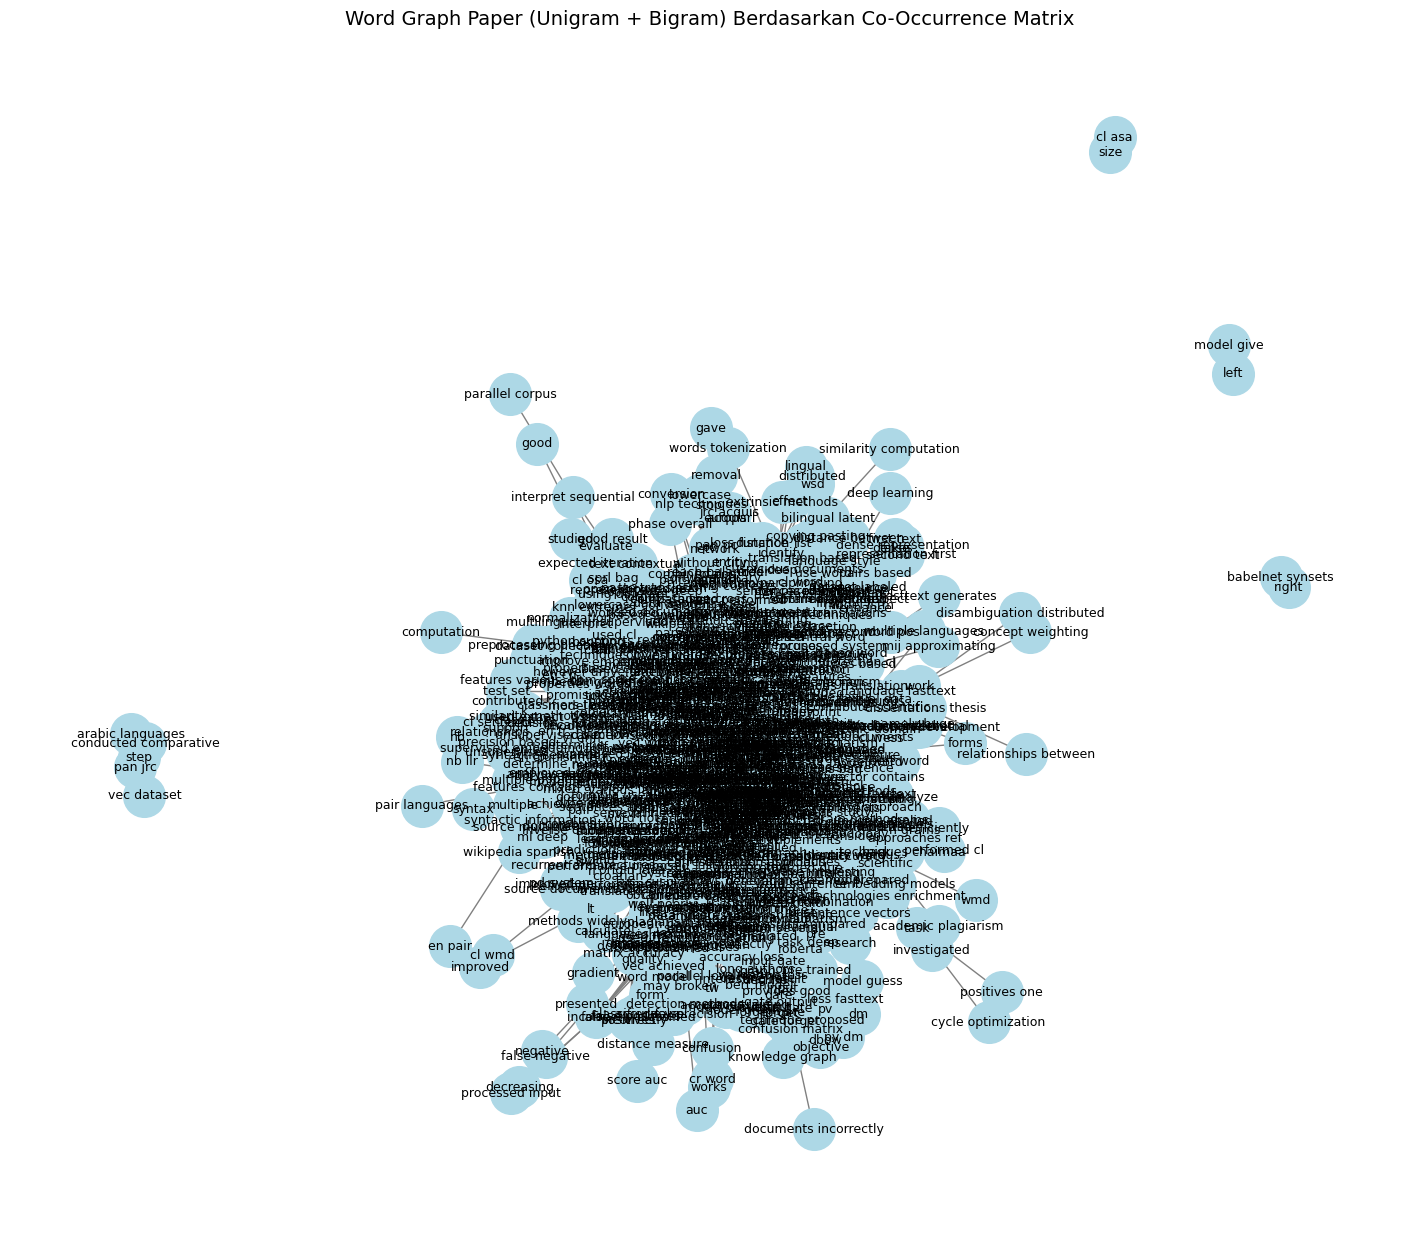

In [ ]:
# Visualisasi Word Graph
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(G_pruned, k=0.7, seed=42)

nx.draw(
    G_pruned,
    pos,
    with_labels=True,
    node_size=900,
    node_color='lightblue',
    font_size=9,
    edge_color='gray'
)

plt.title(
    "Word Graph Paper (Unigram + Bigram) Berdasarkan Co-Occurrence Matrix",
    fontsize=14
)
plt.show()

# **10. Centrality (PageRank)**

In [ ]:
pagerank_scores = nx.pagerank(G)

pagerank_df = pd.DataFrame(
    pagerank_scores.items(),
    columns=['token', 'pagerank']
).sort_values(by='pagerank', ascending=False)

print("Top 20 PageRank Centrality")
display(pagerank_df.head(20))

Top 20 PageRank Centrality


,token,pagerank
6,word,0.007512
97,model,0.005451
96,vec,0.005359
449,used,0.004324
114,cl,0.004119
8,techniques,0.004022
51,language,0.003880
20,plagiarism,0.003782
43,embedding,0.003336
78,using,0.003211


# **11.Degree Centrality**

In [ ]:
degree_scores = nx.degree_centrality(G)

degree_df = pd.DataFrame(
    degree_scores.items(),
    columns=['token', 'degree_centrality']
).sort_values(by='degree_centrality', ascending=False)

print("Top 20 Degree Centrality")
display(degree_df.head(20))

Top 20 Degree Centrality


,token,degree_centrality
6,word,0.329415
97,model,0.220411
96,vec,0.220144
449,used,0.196901
8,techniques,0.189955
51,language,0.187817
20,plagiarism,0.187550
114,cl,0.179001
43,embedding,0.162169
78,using,0.146674


# **12. Beetween Centrality**

In [ ]:
betweenness_scores = nx.betweenness_centrality(G)

betweenness_df = pd.DataFrame(
    betweenness_scores.items(),
    columns=['token', 'betweenness_centrality']
).sort_values(by='betweenness_centrality', ascending=False)

print("Top 20 Betweenness Centrality")
display(betweenness_df.head(20))

Top 20 Betweenness Centrality


,token,betweenness_centrality
6,word,0.104542
97,model,0.058461
449,used,0.044686
20,plagiarism,0.041870
8,techniques,0.031721
96,vec,0.030507
51,language,0.029260
78,using,0.028427
114,cl,0.027774
43,embedding,0.020118


# **13. Closeness Centrality**

In [ ]:
closeness_scores = nx.closeness_centrality(G)

closeness_df = pd.DataFrame(
    closeness_scores.items(),
    columns=['token', 'closeness_centrality']
).sort_values(by='closeness_centrality', ascending=False)

print("Top 20 Closeness Centrality")
display(closeness_df.head(20))

Top 20 Closeness Centrality


,token,closeness_centrality
6,word,0.594901
97,model,0.552138
96,vec,0.551649
20,plagiarism,0.544091
51,language,0.542352
8,techniques,0.541958
43,embedding,0.537820
149,methods,0.526591
932,pairs,0.526146
50,performance,0.524815


# **14. Merge Centrality**

In [ ]:
centrality_df = pagerank_df \
    .merge(degree_df, on='token') \
    .merge(betweenness_df, on='token') \
    .merge(closeness_df, on='token')

display(centrality_df.head(20))

,token,pagerank,degree_centrality,betweenness_centrality,closeness_centrality
0,word,0.007512,0.329415,0.104542,0.594901
1,model,0.005451,0.220411,0.058461,0.552138
2,vec,0.005359,0.220144,0.030507,0.551649
3,used,0.004324,0.196901,0.044686,0.516250
4,cl,0.004119,0.179001,0.027774,0.517539
5,techniques,0.004022,0.189955,0.031721,0.541958
6,language,0.003880,0.187817,0.029260,0.542352
7,plagiarism,0.003782,0.187550,0.041870,0.544091
8,embedding,0.003336,0.162169,0.020118,0.537820
9,using,0.003211,0.146674,0.028427,0.522610


# **15. Normalisasi**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

centrality_df[['pagerank_norm',
               'degree_norm',
               'betweenness_norm',
               'closeness_norm']] = scaler.fit_transform(
    centrality_df[['pagerank',
                    'degree_centrality',
                    'betweenness_centrality',
                    'closeness_centrality']]
)

display(centrality_df.head(20))

,token,pagerank,degree_centrality,betweenness_centrality,closeness_centrality,pagerank_norm,degree_norm,betweenness_norm,closeness_norm
0,word,0.007512,0.329415,0.104542,0.594901,1.000000,1.000000,1.000000,1.000000
1,model,0.005451,0.220411,0.058461,0.552138,0.724141,0.669100,0.559210,0.928117
2,vec,0.005359,0.220144,0.030507,0.551649,0.711892,0.668289,0.291815,0.927294
3,used,0.004324,0.196901,0.044686,0.516250,0.573343,0.597729,0.427445,0.867791
4,cl,0.004119,0.179001,0.027774,0.517539,0.545825,0.543390,0.265674,0.869957
5,techniques,0.004022,0.189955,0.031721,0.541958,0.532935,0.576642,0.303430,0.911005
6,language,0.003880,0.187817,0.029260,0.542352,0.513868,0.570154,0.279890,0.911666
7,plagiarism,0.003782,0.187550,0.041870,0.544091,0.500790,0.569343,0.400506,0.914590
8,embedding,0.003336,0.162169,0.020118,0.537820,0.441038,0.492295,0.192442,0.904048
9,using,0.003211,0.146674,0.028427,0.522610,0.424401,0.445255,0.271924,0.878482


In [ ]:
centrality_df['aggregate_score'] = (
    centrality_df['pagerank_norm'] +
    centrality_df['degree_norm'] +
    centrality_df['betweenness_norm'] +
    centrality_df['closeness_norm']
)

centrality_df = centrality_df.sort_values(
    by='aggregate_score',
    ascending=False
)

# **16. Agregat Score**

In [ ]:
# hasil keyword ekstraksion berdasarkan hasil agregat semua centrality
top_keywords_aggregate = centrality_df[
    ['token', 'aggregate_score']
].head(20)

print("Top 20 Kata Kunci Berdasarkan Agregat Semua Centrality")
display(top_keywords_aggregate)

Top 20 Kata Kunci Berdasarkan Agregat Semua Centrality


,token,aggregate_score
0,word,4.000000
1,model,2.880567
2,vec,2.599290
3,used,2.466308
7,plagiarism,2.385228
5,techniques,2.324013
6,language,2.275579
4,cl,2.224846
8,embedding,2.029823
9,using,2.020063


# **17. Visualisasi Keyword**

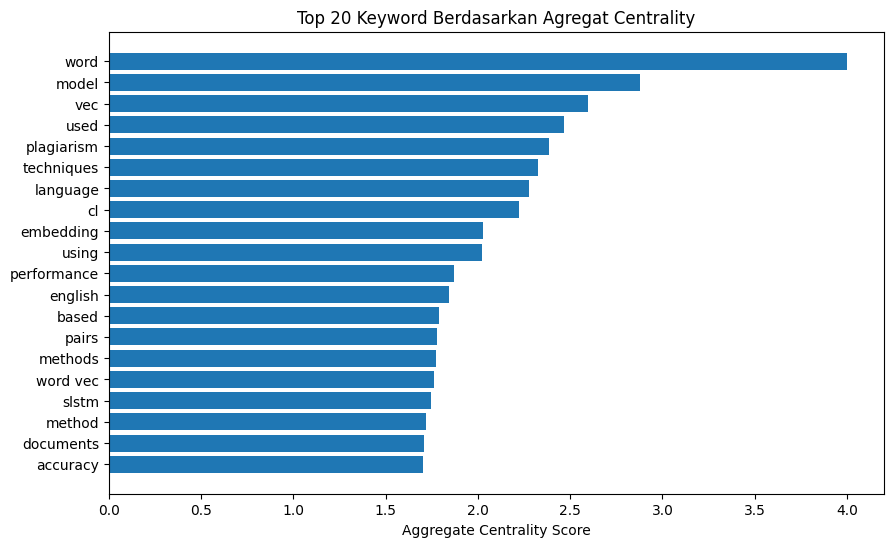

In [ ]:
# visualisasi keyword ekstraksion
plt.figure(figsize=(10, 6))
plt.barh(
    top_keywords_aggregate['token'],
    top_keywords_aggregate['aggregate_score']
)
plt.gca().invert_yaxis()
plt.title("Top 20 Keyword Berdasarkan Agregat Centrality")
plt.xlabel("Aggregate Centrality Score")
plt.show()